The notebook is designed to plot the comparison how hidden layer size affects:

the distribution of information atoms in decision-making RNNs,

task performance,

and the relative contribution of synergy and redundancy.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


# ============================
# Load all results
# ============================

RESULT_DIR = Path(
    r"E:\TUM\3sem\NeuroAI\project\github_neuroai\size_comparison\data_loading_ver\results"
)

files = sorted(RESULT_DIR.glob("results_*.npz"))


sizes = []

cdm_pid = {
    "synergy": [],
    "redundancy": [],
    "unique1": [],
    "unique2": [],
    "total": []
}

pdm_pid = {
    "synergy": [],
    "redundancy": [],
    "unique1": [],
    "unique2": [],
    "total": []
}

accuracy = {
    "CDM": [],
    "PDM": []
}

loss = {
    "CDM": [],
    "PDM": []
}

for file in files:

    # Extract model size from filename
    # results_100.npz -> 100
    size = int(file.stem.split("_")[1])
    sizes.append(size)

    data = np.load(file, allow_pickle=True)


    # ============================
    # CDM coherence PID
    # ============================

    cdm_pid["synergy"].append(
        data["cdm_coherence_synergy"]
    )

    cdm_pid["redundancy"].append(
        data["cdm_coherence_redundancy"]
    )

    cdm_pid["unique1"].append(
        data["cdm_coherence_unique1"]
    )

    cdm_pid["unique2"].append(
        data["cdm_coherence_unique2"]
    )

    cdm_pid["total"].append(
        data["cdm_coherence_mi_joint"]
    )


    # ============================
    # PDM coherence PID
    # ============================

    pdm_pid["synergy"].append(
        data["pdm_decision_synergy"]
    )

    pdm_pid["redundancy"].append(
        data["pdm_decision_redundancy"]
    )

    pdm_pid["unique1"].append(
        data["pdm_decision_unique1"]
    )

    pdm_pid["unique2"].append(
        data["pdm_decision_unique2"]
    )

    pdm_pid["total"].append(
        data["pdm_decision_mi_joint"]
    )

    # ============================
    # Test accuracy
    # ============================

    accuracy["CDM"].append(
        data[f"cdm_{size}_test_acc"]
    )

    accuracy["PDM"].append(
        data[f"pdm_{size}_test_acc"]
    )
    # ============================
    # Test loss
    # ============================
    loss["CDM"].append(data[f"cdm_{size}_test_loss"])
    loss["PDM"].append(data[f"pdm_{size}_test_loss"])


# ============================
# Sort by model size
# ============================

idx = np.argsort(sizes)

sizes = np.array(sizes)[idx]


for key in cdm_pid:
    cdm_pid[key] = np.array(cdm_pid[key])[idx]
    pdm_pid[key] = np.array(pdm_pid[key])[idx]


accuracy["CDM"] = np.array(accuracy["CDM"])[idx]
accuracy["PDM"] = np.array(accuracy["PDM"])[idx]
loss["CDM"] = np.array(loss["CDM"])[idx]
loss["PDM"] = np.array(loss["PDM"])[idx]

print("Model sizes:")
print(sizes)

Model sizes:
[  2   4   8  12  16  20  40  60  80 100 150 200]


## Model Scaling Analysis

This analysis examines how increasing the recurrent model size affects three complementary measures of performance for both the Contextual Decision Making (CDM) and Perceptual Decision Making (PDM) tasks.

For each trained model size:

- **Test accuracy** is plotted on the primary y-axis to measure generalization performance.
- **Validation performance** is represented as **1 − validation loss** on the secondary y-axis so that larger values consistently indicate better performance, making it directly comparable to accuracy.
- **Total mutual information** (`MI_joint`) at a selected time point (time index 105) is plotted on a third y-axis. This quantity measures the total information encoded by the network about the task-relevant variable (context/coherence for CDM or decision for PDM).

Separate figures are generated for the CDM and PDM tasks. Each figure therefore illustrates how network scaling influences:

1. Behavioral performance (test accuracy),
2. Optimization quality (1 − validation loss), and
3. The amount of task-relevant information represented in the network.

The three metrics are displayed using independent y-axes because they have different numerical scales, while sharing the same x-axis corresponding to model size.

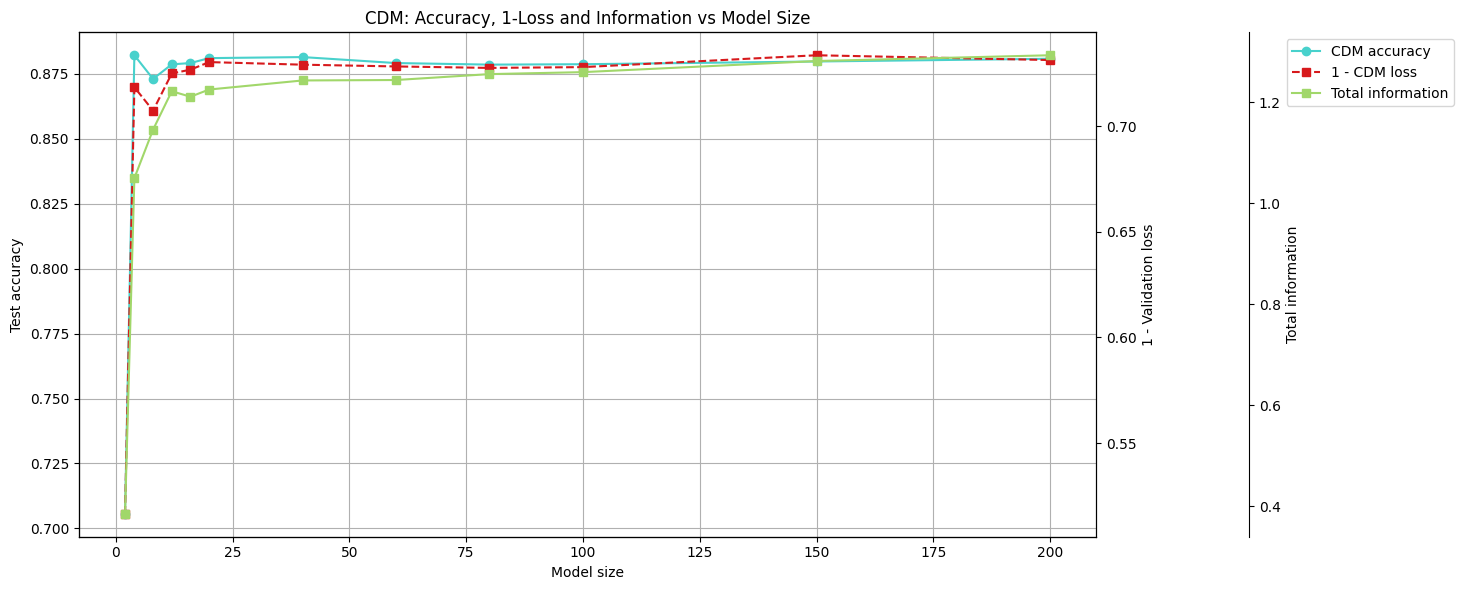

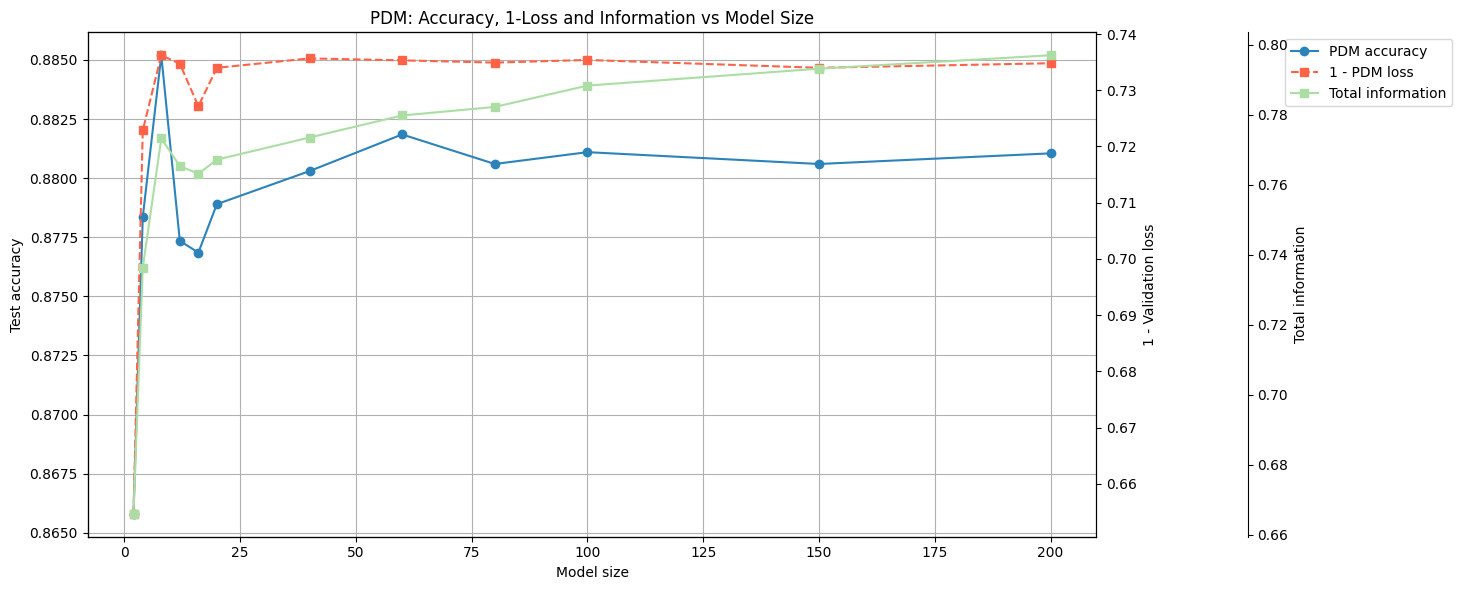

In [ ]:
inv_loss = {
    "CDM": 1 - loss["CDM"],
    "PDM": 1 - loss["PDM"]
}


# ============================
# CDM plot
# ============================

fig, ax1 = plt.subplots(figsize=(15, 6))

ax1.plot(
    sizes,
    accuracy["CDM"],
    marker="o",
    label="CDM accuracy",
    color="mediumturquoise"
)

ax1.set_xlabel("Model size")
ax1.set_ylabel("Test accuracy")
ax1.grid(True)

# Loss axis
ax2 = ax1.twinx()

ax2.plot(
    sizes,
    inv_loss["CDM"],
    marker="s",
    linestyle="--",
    label="1 - CDM loss",
    color="#d7191c"
)

ax2.set_ylabel("1 - Validation loss")


# PID information axis
ax3 = ax1.twinx()

ax3.spines["right"].set_position(("axes", 1.15))

ax3.plot(
    sizes,
    cdm_pid["total"][:, 105],
    marker="s",
    linestyle="-",
    label="Total information",
    color="#a1d76a"
)

ax3.set_ylabel("Total information")


# Combined legend
lines = []
labels = []

for ax in [ax1, ax2, ax3]:
    l, lab = ax.get_legend_handles_labels()
    lines.extend(l)
    labels.extend(lab)

ax1.legend(
    lines,
    labels,
    loc="upper left",
    bbox_to_anchor=(1.18, 1),
    frameon=True
)

plt.title("CDM: Accuracy, 1-Loss and Information vs Model Size")

plt.tight_layout()
plt.savefig("results/cdm_metrics_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

# ============================
# PDM plot
# ============================

fig, ax1 = plt.subplots(figsize=(15, 6))

ax1.plot(
    sizes,
    accuracy["PDM"],
    marker="o",
    label="PDM accuracy",
    color="#2b83ba"
)

ax1.set_xlabel("Model size")
ax1.set_ylabel("Test accuracy")
ax1.grid(True)


# Loss axis
ax2 = ax1.twinx()

ax2.plot(
    sizes,
    inv_loss["PDM"],
    marker="s",
    linestyle="--",
    label="1 - PDM loss",
    color="tomato"
)

ax2.set_ylabel("1 - Validation loss")


# PID axis
ax3 = ax1.twinx()

ax3.spines["right"].set_position(("axes", 1.15))

ax3.plot(
    sizes,
    pdm_pid["total"][:,105],
    marker="s",
    linestyle="-",
    label="Total information",
    color="#abdda4"
)

ax3.set_ylabel("Total information")


# Combined legend
lines = []
labels = []

for ax in [ax1, ax2, ax3]:
    l, lab = ax.get_legend_handles_labels()
    lines.extend(l)
    labels.extend(lab)

ax1.legend(
    lines,
    labels,
    loc="upper left",
    bbox_to_anchor=(1.18, 1),
    frameon=True
)

plt.title("PDM: Accuracy, 1-Loss and Information vs Model Size")

plt.tight_layout()
plt.savefig("results/pdm_metrics_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

## PID Component Analysis Across Model Sizes

This analysis investigates how different Partial Information Decomposition (PID) components vary as the recurrent model size increases for the Contextual Decision Making (CDM) and Perceptual Decision Making (PDM) task.

For each model size, the following information-theoretic quantities are extracted at **time step 105** which is the start point of decision time, corresponding to a late stage of the trial after the stimulus has been processed:

- **Redundancy** – information about the target shared by both neural populations.
- **Unique1** – information provided exclusively by the first neural population.
- **Unique2** – information provided exclusively by the second neural population.
- **Synergy** – information that can only be recovered when both populations are considered jointly.
- **Total information** – the joint mutual information between both populations and the task variable.

Each PID component is plotted as a function of model size using a consistent color scheme. This visualization allows direct comparison of how network scaling influences different modes of information representation, revealing whether larger models primarily increase redundant, unique, or synergistic information, or simply increase the total amount of encoded task-relevant information.

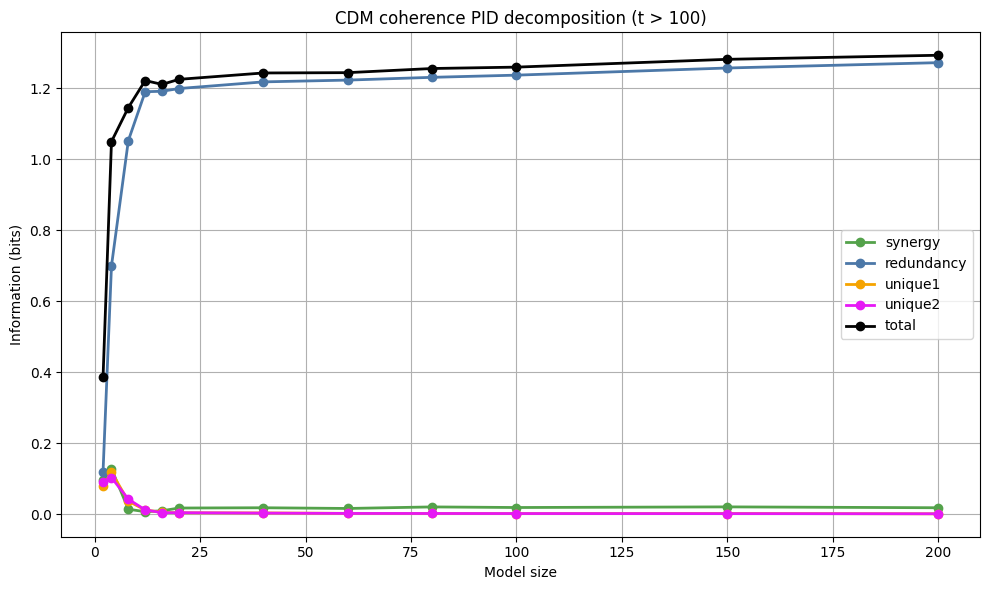

In [ ]:

ATOM_COLORS = {
    'total':      '#020202',   # black
    'redundancy': '#4C78A8',   # blue
    'unique1':    '#F5A300',   # orange
    'unique2':    '#E618F5',   # purple
    'synergy':    '#54A24B',   # green
}

components = [
    "synergy",
    "redundancy",
    "unique1",
    "unique2",
    "total"
]

# average over time dimension after step 105# decision PID
cdm_pid_line = {}

for comp in components:
    cdm_pid_line[comp] = cdm_pid[comp][:, 105]   # time step 105

    


plt.figure(figsize=(10, 6))

for comp in components:
    plt.plot(
        sizes,
        cdm_pid_line[comp],
        marker="o",
        linewidth=2,
        label=comp,
        color=ATOM_COLORS[comp]
    )

plt.xlabel("Model size")
plt.ylabel("Information (bits)")
plt.title("CDM coherence PID decomposition (t > 100)")

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("results/pid_cdm_coherence_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

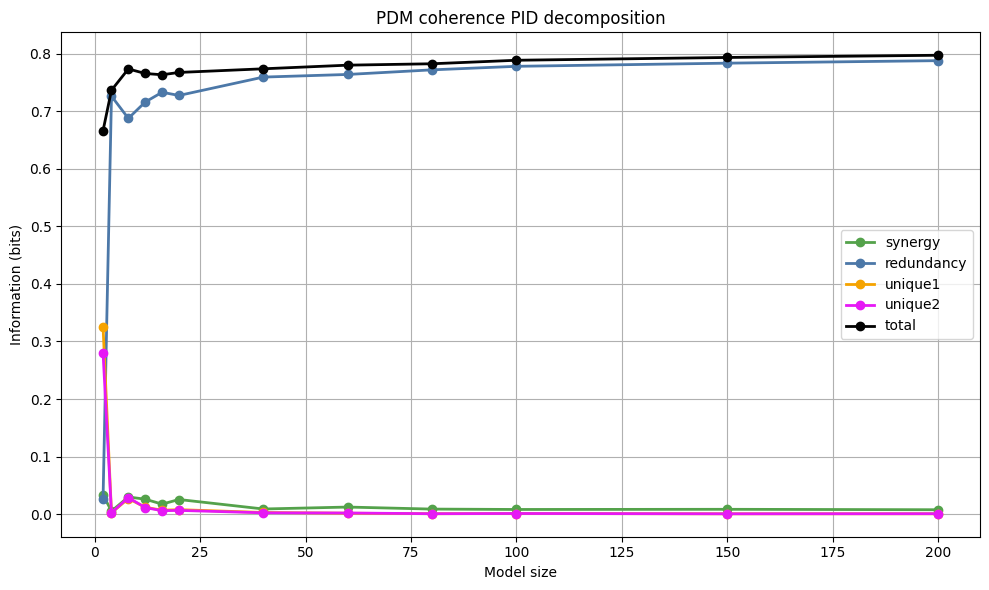

In [ ]:



ATOM_COLORS = {
    'total':      '#020202',   # black
    'redundancy': '#4C78A8',   # blue
    'unique1':    '#F5A300',   # orange
    'unique2':    '#E618F5',   # purple
    'synergy':    '#54A24B',   # green
}

components = [
    "synergy",
    "redundancy",
    "unique1",
    "unique2",
    "total"
]

# average over time dimension
pdm_pid_line = {}

for comp in components:
    pdm_pid_line[comp] = pdm_pid[comp][:, 105]

plt.figure(figsize=(10, 6))

for comp in components:
    plt.plot(
        sizes,
        pdm_pid_line[comp],
        marker="o",
        linewidth=2,
        label=comp,
        color=ATOM_COLORS[comp]
    )


plt.xlabel("Model size")
plt.ylabel("Information (bits)")
plt.title("PDM coherence PID decomposition")

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("results/pid_pdm_coherence_comparison.png", dpi=300, bbox_inches='tight')
plt.show()



For each trained model, the **test accuracy** is plotted as a function of model size. The two tasks are displayed on the same figure to facilitate direct comparison of their scaling behavior.



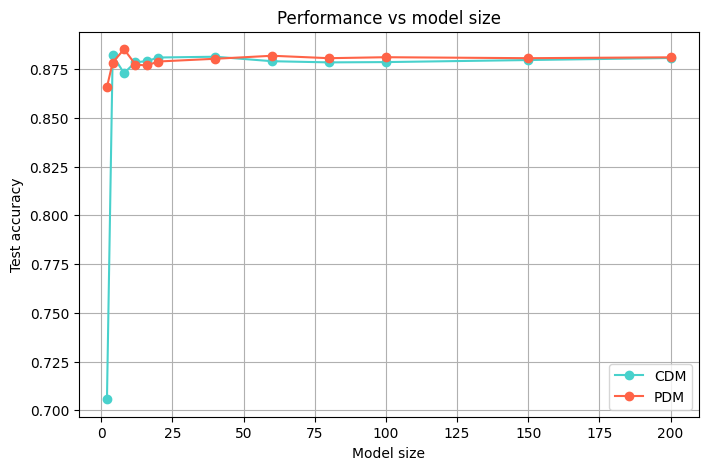

In [ ]:
plt.figure(figsize=(8,5))
palette=["mediumturquoise", "tomato"]
plt.plot(
    sizes,
    accuracy["CDM"],
    marker="o",
    label="CDM",
    color=palette[0]
)

plt.plot(
    sizes,
    accuracy["PDM"],
    marker="o",
    label="PDM",
    color=palette[1]
)

plt.xlabel("Model size")
plt.ylabel("Test accuracy")
plt.title("Performance vs model size")

plt.legend()
plt.grid(True)

plt.savefig("results/performance_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

## Relative Information Composition

This analysis examines how the composition of task-relevant information changes as the recurrent model size increases. Rather than plotting the absolute values of the PID components, the **synergy** and **redundancy** terms are normalized by the **total mutual information**, providing a measure of the relative contribution of each information type.

For both the Contextual Decision Making (CDM) and Perceptual Decision Making (PDM) tasks, the following ratios are computed at the selected decision time point:

- **Synergy / Total Information** – the fraction of information that is only available when the two neural populations are considered jointly.
- **Redundancy / Total Information** – the fraction of information that is shared between the two neural populations.

Plotting these normalized quantities reveals whether increasing model size changes **how** information is represented, rather than simply increasing the total amount of encoded information. In particular, it highlights whether larger recurrent networks rely more heavily on synergistic or redundant representations during decision making.

In [ ]:

start = 105

CDMmean_syn = cdm_pid["synergy"][:, start]
CDMmean_red = cdm_pid["redundancy"][:, start]
CDMmean_total = cdm_pid["total"][:, start]

cdm_syn_ratio = CDMmean_syn / CDMmean_total
cdm_red_ratio = CDMmean_red / CDMmean_total


PDMmean_syn = pdm_pid["synergy"][:, start]
PDMmean_red = pdm_pid["redundancy"][:, start]
PDMmean_total = pdm_pid["total"][:, start]

pdm_syn_ratio = PDMmean_syn / PDMmean_total
pdm_red_ratio = PDMmean_red / PDMmean_total


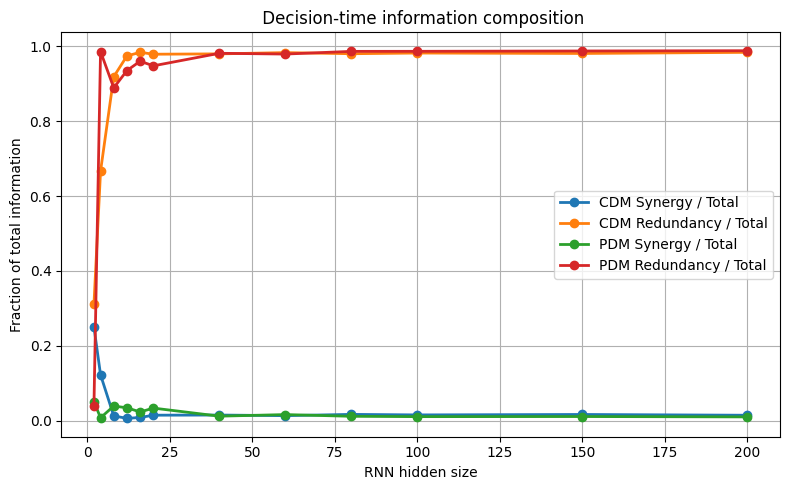

In [58]:
plt.figure(figsize=(8,5))

plt.plot(sizes, cdm_syn_ratio,
         marker="o",
         linewidth=2,
         label="CDM Synergy / Total")

plt.plot(sizes, cdm_red_ratio,
         marker="o",
         linewidth=2,
         label="CDM Redundancy / Total")

plt.plot(sizes, pdm_syn_ratio,
         marker="o",
         linewidth=2,
         label="PDM Synergy / Total")

plt.plot(sizes, pdm_red_ratio,
         marker="o",
         linewidth=2,
         label="PDM Redundancy / Total")

plt.xlabel("RNN hidden size")
plt.ylabel("Fraction of total information")
plt.title(" Decision-time information composition")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

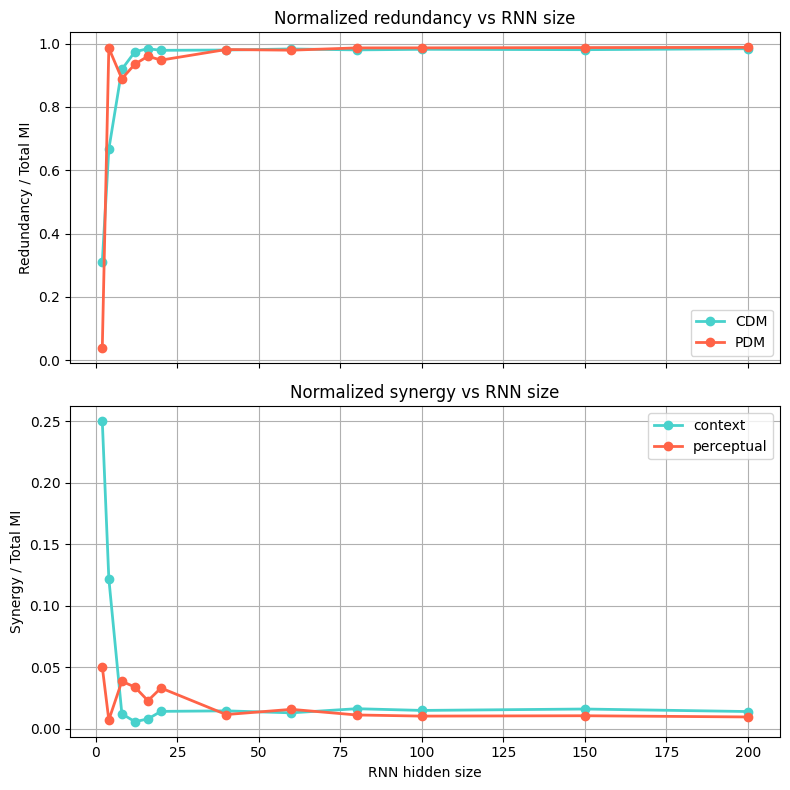

In [59]:

palette=["mediumturquoise", "tomato"]
fig, axes = plt.subplots(
    2, 1,
    figsize=(8, 8),
    sharex=True
)

# ======================
# Top: Redundancy
# ======================
axes[0].plot(
    sizes,
    cdm_red_ratio,
    marker="o",
    linewidth=2,
    label="CDM",
    color=palette[0]
)

axes[0].plot(
    sizes,
    pdm_red_ratio,
    marker="o",
    linewidth=2,
    label="PDM",
    color=palette[1]
)

axes[0].set_ylabel("Redundancy / Total MI")
axes[0].set_title("Normalized redundancy vs RNN size")
axes[0].grid(True)
axes[0].legend()


# ======================
# Bottom: Synergy
# ======================
axes[1].plot(
    sizes,
    cdm_syn_ratio,
    marker="o",
    linewidth=2,
    label="context",
    color=palette[0]
)

axes[1].plot(
    sizes,
    pdm_syn_ratio,
    marker="o",
    linewidth=2,
    label="perceptual",
    color=palette[1]
)

axes[1].set_xlabel("RNN hidden size")
axes[1].set_ylabel("Synergy / Total MI")
axes[1].set_title("Normalized synergy vs RNN size")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

## Information Composition: Redundancy–Synergy Balance

This analysis investigates the balance between redundant and synergistic information representations during decision making and how this balance changes with recurrent neural network (RNN) size.

The relative dominance of redundancy versus synergy is quantified using the normalized metric:

$\frac{\text{Redundancy} - \text{Synergy}}{\text{Total Information}}$

The metric is evaluated at **decision time (time step 105)** for both:

- **Contextual Decision Making (CDM)**
- **Perceptual Decision Making (PDM)**

The first plot compares the redundancy–synergy balance across different RNN hidden sizes, allowing assessment of whether scaling the network changes the preferred information-sharing strategy.

---

## Distribution of Total Information During Decision Time

To examine the temporal evolution and variability of information encoding after decision onset, the total mutual information is extracted from **time step 105 onward**.

plots are used to visualize the range of total information across the decision period for each RNN size separately for

Together, these analyses reveal both:
1. How model scaling changes the **relative organization of information** (redundancy versus synergy), and  
2. How scaling affects the **amount and temporal stability of task-relevant information** encoded during the decision process.

C:\Users\USER\AppData\Local\Temp\ipykernel_18856\347686444.py:12: RuntimeWarning: invalid value encountered in divide
  PDM_diff = (pdm_red - pdm_syn)/pdm_total


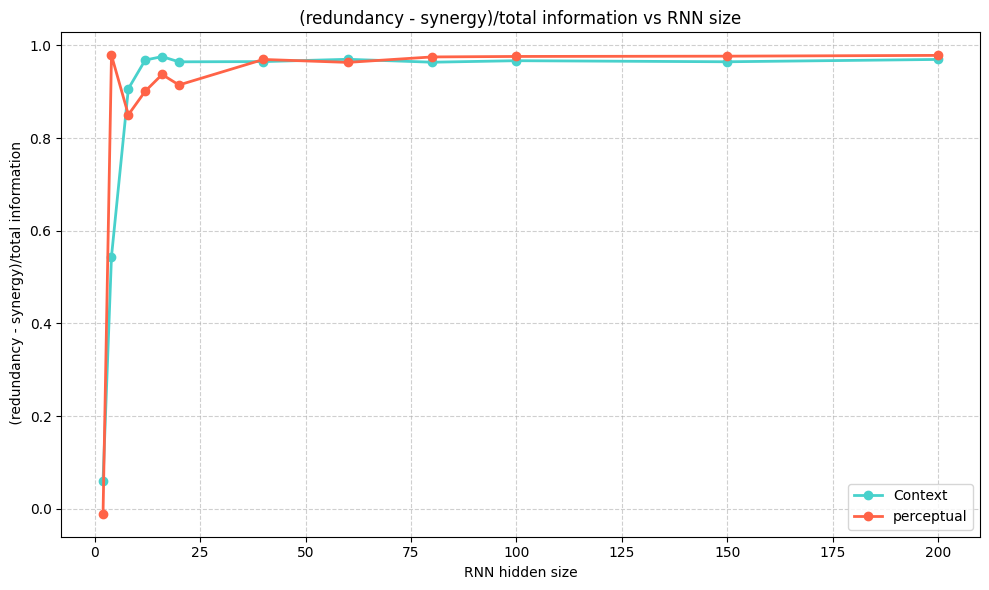

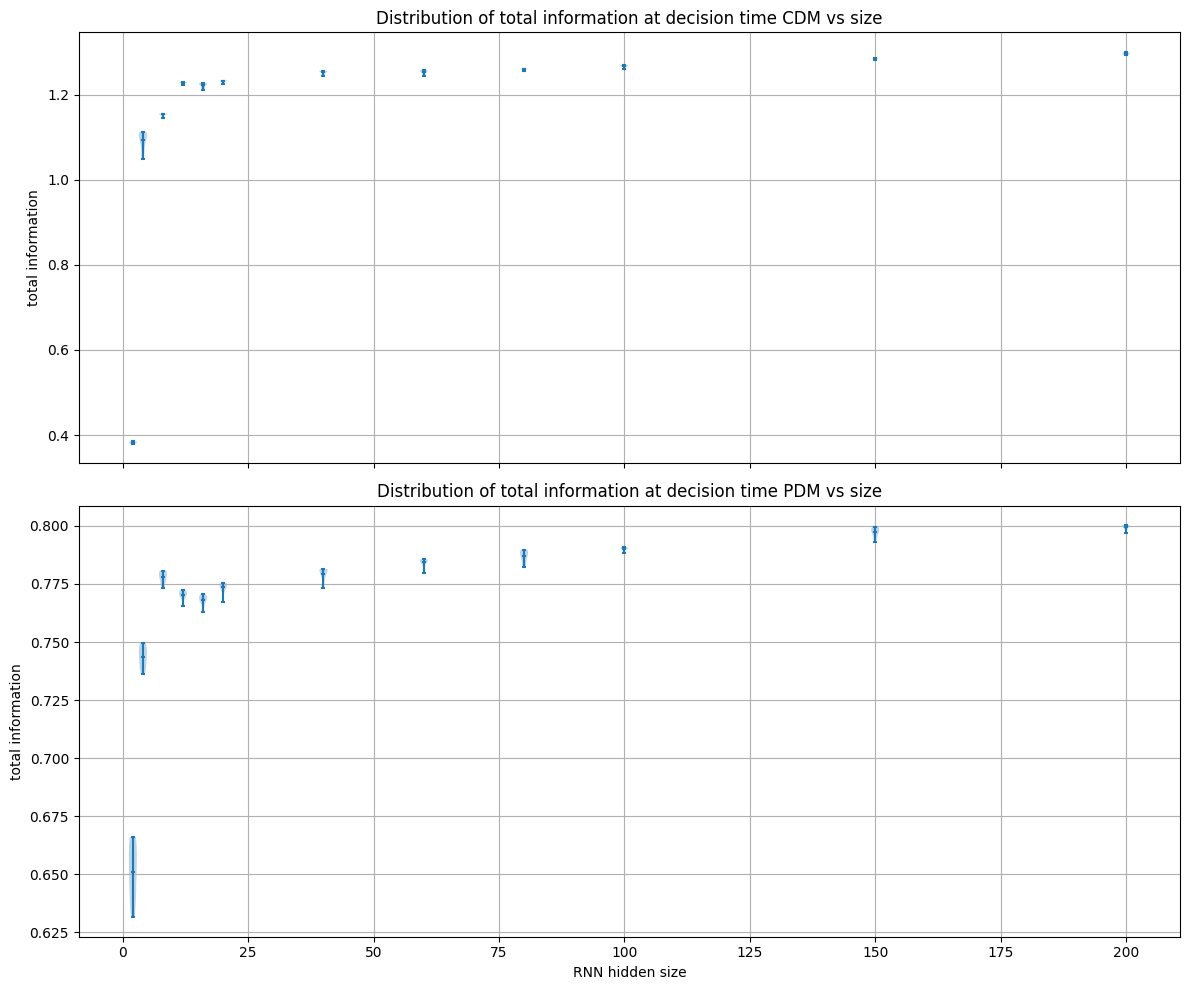

In [ ]:
# Compute CDM-PDM differences for synergy and redundancy
start = 105

cdm_syn = cdm_pid["synergy"]
pdm_syn = pdm_pid["synergy"]
cdm_red = cdm_pid["redundancy"]
pdm_red = pdm_pid["redundancy"]
cdm_total = cdm_pid["total"]
pdm_total = pdm_pid["total"]

CDM_diff = (cdm_red - cdm_syn)/cdm_total
PDM_diff = (pdm_red - pdm_syn)/pdm_total

CDM_diff_mean = CDM_diff[:, start]
PDM_diff_mean = PDM_diff[:, start]
palette=["mediumturquoise", "tomato"]
# Plot mean difference with logarithmic (symlog) y-axis
plt.figure(figsize=(10, 6))
plt.plot(sizes, CDM_diff_mean, marker="o", linewidth=2, label="Context", color=palette[0])
plt.plot(sizes, PDM_diff_mean, marker="o", linewidth=2, label="perceptual", color=palette[1])

plt.xlabel("RNN hidden size")
plt.ylabel(" (redundancy - synergy)/total information")
plt.title(" (redundancy - synergy)/total information vs RNN size ")
#plt.yscale("symlog", linthresh=1e-3)
plt.grid(True, which="both", linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.savefig("results/redundancy_synergy_balance_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

# Violin plots of the difference distributions after decision onset

CDM_data = [cdm_total[i, start:] for i in range(len(sizes))]
PDM_data = [pdm_total[i, start:] for i in range(len(sizes))]

fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
width = max(1.0, (sizes[1] - sizes[0]) * 0.8 if len(sizes) > 1 else 1.0)

axes[0].violinplot(CDM_data, positions=sizes, widths=width, showmeans=True)
axes[0].set_title("Distribution of total information at decision time CDM vs size")
axes[0].set_ylabel("total information")
axes[0].grid(True)

axes[1].violinplot(PDM_data, positions=sizes, widths=width, showmeans=True)
axes[1].set_title("Distribution of total information at decision time PDM vs size")
axes[1].set_xlabel("RNN hidden size")
axes[1].set_ylabel("total information")
axes[1].grid(True)

plt.tight_layout()
plt.show()

## Distribution of Information Components Across Tasks and Model Sizes

This analysis compares the distribution of different Partial Information Decomposition (PID) components between the Contextual Decision Making (CDM) and Perceptual Decision Making (PDM) tasks.

For each RNN hidden size, PID components are normalized relative to the total information:

$\text{Normalized Information Component}=\frac{\text{PID Component}}{\text{Total Information}}$

This normalization allows comparison of the **relative information composition** independent of differences in absolute mutual information between models.

The following components are analyzed:

- **Total information** – normalized to 1 and used as a reference for each model.
- **Synergy fraction** – proportion of total information that is available only through the joint activity of the two neural populations.
- **Redundancy fraction** – proportion of total information shared between the two neural populations.

For each component, violin plots show the distribution across RNN model sizes separately for:

- **CDM**
- **PDM**

Individual points represent the contribution from each RNN hidden size, with point color indicating the corresponding model size. This visualization allows assessment of whether scaling the network changes the relative contribution of synergistic and redundant information and whether CDM and PDM rely on different information encoding strategies.

The comparison focuses on **decision-time information (t ≥ 105)**, where the network has accumulated task-relevant evidence and generated decision-related representations.

C:\Users\USER\AppData\Local\Temp\ipykernel_18856\4082294369.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\USER\AppData\Local\Temp\ipykernel_18856\4082294369.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\USER\AppData\Local\Temp\ipykernel_18856\4082294369.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


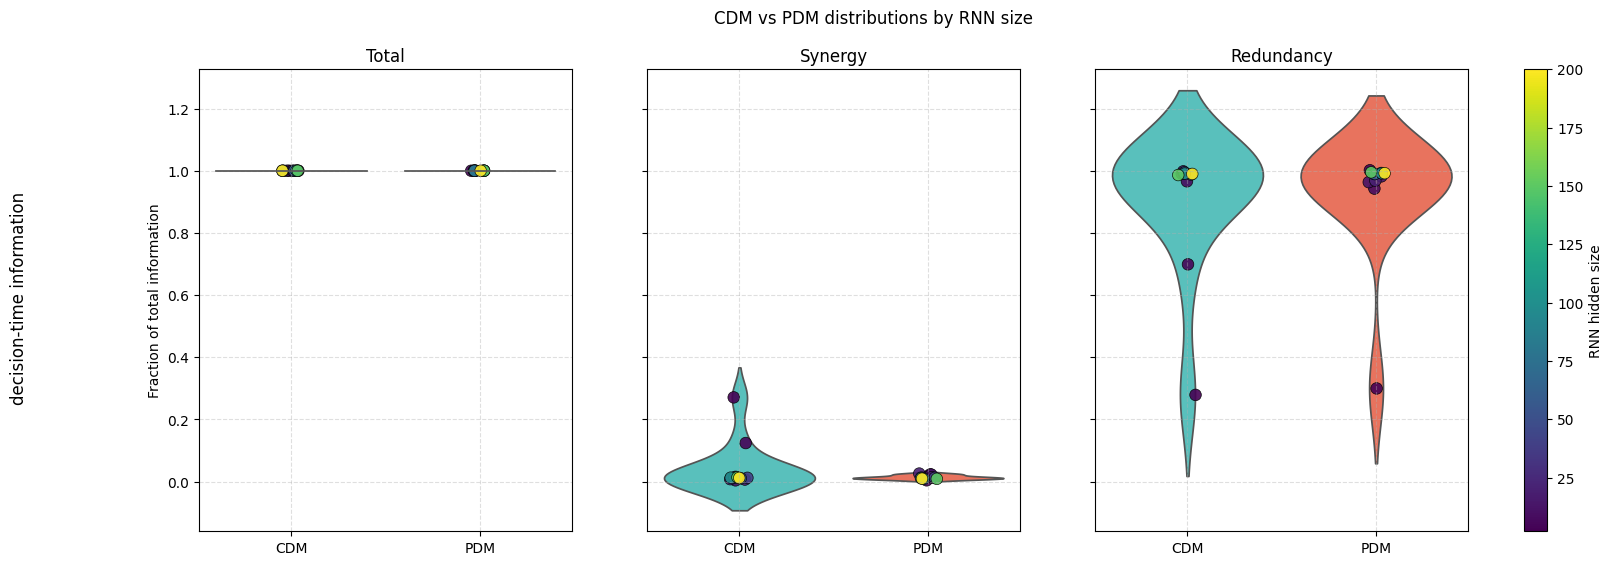

In [77]:
import seaborn as sns
import pandas as pd

# ...existing code...

start = 105

# Decision-time averages for each component, normalized by total
summary = []
for i, size in enumerate(sizes):
    cdm_total_mean = cdm_pid["total"][i, start]
    pdm_total_mean = pdm_pid["total"][i, start]

    summary.append({
        "task": "CDM",
        "component": "total",
        "size": size,
        "value": 1.0
    })
    summary.append({
        "task": "PDM",
        "component": "total",
        "size": size,
        "value": 1.0
    })
    summary.append({
        "task": "CDM",
        "component": "synergy",
        "size": size,
        "value": np.mean(cdm_pid["synergy"][i, start:]) / cdm_total_mean
    })
    summary.append({
        "task": "PDM",
        "component": "synergy",
        "size": size,
        "value": np.mean(pdm_pid["synergy"][i, start:]) / pdm_total_mean
    })
    summary.append({
        "task": "CDM",
        "component": "redundancy",
        "size": size,
        "value": np.mean(cdm_pid["redundancy"][i, start:]) / cdm_total_mean
    })
    summary.append({
        "task": "PDM",
        "component": "redundancy",
        "size": size,
        "value": np.mean(pdm_pid["redundancy"][i, start:]) / pdm_total_mean
    })

df = pd.DataFrame(summary)



palette = sns.color_palette("viridis", as_cmap=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
for ax, component in zip(axes, ["total", "synergy", "redundancy"]):
    comp_df = df[df["component"] == component]
    sns.violinplot(
        x="task",
        y="value",
        data=comp_df,
        inner=None,
        palette=["mediumturquoise", "tomato"],
        ax=ax,
    )
    
    # Scatter each size as a point with color encoding size
    norm = plt.Normalize(vmin=sizes.min(), vmax=sizes.max())
    cmap = plt.cm.viridis

    for task_val, x_pos in [("CDM", -0.1), ("PDM", 0.1)]:
        task_df = comp_df[comp_df["task"] == task_val]
        xs = np.full(len(task_df), 0 if task_val == "CDM" else 1) + np.random.uniform(-0.05, 0.05, len(task_df))
        ax.scatter(
            xs,
            task_df["value"],
            c=task_df["size"],
            cmap=cmap,
            norm=norm,
            edgecolor="black",
            linewidth=0.5,
            s=70,
            alpha=0.9,
        )

    ax.set_ylabel("Fraction of total information")
    ax.set_title(component.capitalize())
    ax.set_xlabel("")
    
    ax.grid(True, linestyle="--", alpha=0.4)

fig.supylabel("decision-time information")
fig.suptitle("CDM vs PDM distributions by RNN size")
cb = fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=axes, orientation="vertical", fraction=0.05, pad=0.04)
cb.set_label("RNN hidden size")
plt.show()